PIPELINE FOR NYC TAXi


NYC Taxi - 1.4M rows, geospatial, temporal patterns


## NYC Taxi Trip Duration Prediction

### Problem Statement
Predict taxi trip duration in NYC using geospatial and temporal features from the NYC Taxi dataset (1.4M records).

### Dataset
- **Size**: 1.4M rows
- **Task**: Regression (continuous prediction)
- **Target**: Trip duration (in seconds)
- **Features**: Temporal patterns, pickup/dropoff coordinates, passenger count, vendor

### Pipeline Overview
1. **Exploratory Data Analysis** → Understand data distributions and patterns
2. **Feature Engineering** → Create temporal and distance features
3. **Model Training** → Test 7 different algorithms
4. **Hyperparameter Tuning** → Optimize best performing model
5. **Evaluation** → Compare models and analyze results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              )
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error)
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv("train.csv", nrows=100000)
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (100000, 11)
Test Shape: (625134, 9)



## 1. Exploratory Data Analysis (EDA)

In [3]:
print(train.columns)
print(train.dtypes)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='str')
id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
dtype: object


In [4]:
train = train.drop('dropoff_datetime',axis=1)
train = train.drop('store_and_fwd_flag',axis=1)

In [5]:
print(train.columns)
print(train.dtypes)
print(f"no of dublicates :\n {train.duplicated().sum()}")
print(f"no of missing : \n{train.isnull().sum()}")

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'trip_duration'],
      dtype='str')
id                       str
vendor_id              int64
pickup_datetime          str
passenger_count        int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
trip_duration          int64
dtype: object
no of dublicates :
 0
no of missing : 
id                   0
vendor_id            0
pickup_datetime      0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
trip_duration        0
dtype: int64


In [6]:
train = train.drop('id',axis=1)
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])

train['pickup_hour'] = train['pickup_datetime'].dt.hour
train['pickup_day'] = train['pickup_datetime'].dt.day
train['pickup_month'] = train['pickup_datetime'].dt.month
train['pickup_weekday'] = train['pickup_datetime'].dt.weekday

train = train.drop('pickup_datetime',axis=1)

In [7]:
print(train.columns)
print(train.dtypes)
print(f"no of dublicates :\n {train.duplicated().sum()}")
print(f"no of missing : \n{train.isnull().sum()}")
print(f"shape of the data : \n {train.shape}")
print(f"discribe : \n {train.describe()}")

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 'pickup_hour',
       'pickup_day', 'pickup_month', 'pickup_weekday'],
      dtype='str')
vendor_id              int64
passenger_count        int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
trip_duration          int64
pickup_hour            int32
pickup_day             int32
pickup_month           int32
pickup_weekday         int32
dtype: object
no of dublicates :
 0
no of missing : 
vendor_id            0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
trip_duration        0
pickup_hour          0
pickup_day           0
pickup_month         0
pickup_weekday       0
dtype: int64
shape of the data : 
 (100000, 11)
discribe : 
           vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count 

In [8]:
train= train[(train['passenger_count']>0) & (train['passenger_count'] <= 5)]
train= train[(train['trip_duration']) > 60 & (train['trip_duration'] < 7200)]

In [9]:
train['distance'] = np.sqrt(
    (train['pickup_longitude'] - train['dropoff_longitude'])**2 +
    (train['pickup_latitude'] - train['dropoff_latitude'])**2
)
train = train[train['distance'] > 0]
train = train[train['distance'] < 5]

train = train[
    (train['pickup_longitude'] > -75) &
    (train['pickup_longitude'] < -73) &
    (train['dropoff_longitude'] > -75) &
    (train['dropoff_longitude'] < -73) &
    (train['pickup_latitude'] > 40) &
    (train['pickup_latitude'] < 42) &
    (train['dropoff_latitude'] > 40) &
    (train['dropoff_latitude'] < 42)
]

In [10]:
print(train.columns)
print(train.dtypes)
print(f"no of dublicates :\n {train.duplicated().sum()}")
print(f"no of missing : \n{train.isnull().sum()}")
print(f"shape of the data : \n {train.shape}")
print(f"discribe : \n {train.describe()}")

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 'pickup_hour',
       'pickup_day', 'pickup_month', 'pickup_weekday', 'distance'],
      dtype='str')
vendor_id              int64
passenger_count        int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
trip_duration          int64
pickup_hour            int32
pickup_day             int32
pickup_month           int32
pickup_weekday         int32
distance             float64
dtype: object
no of dublicates :
 0
no of missing : 
vendor_id            0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
trip_duration        0
pickup_hour          0
pickup_day           0
pickup_month         0
pickup_weekday       0
distance             0
dtype: int64
shape of the data : 
 (96319, 12)
discribe : 
           vendor_i

In [11]:
def boxplot(data,column= None , figsize=(15,10)):
        numericcolumn = data.select_dtypes(include=[np.number]).columns.tolist()

    # If single column passed
        if column:
            if column not in numericcolumn:
                print(f"Error: '{column}' is not numeric!")
                return
        
            plt.figure(figsize=figsize)
            plt.boxplot(data[column],vert=False)
            plt.title(f'boxplot of {column}',fontsize=14,fontweight='bold')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
            return   
        
        
        n_col = min(len(numericcolumn),9)
        fig,axes = plt.subplots(3,3,figsize=figsize)
        axes= axes.ravel()
        for idx,col in enumerate(numericcolumn[:9]):
            axes[idx].boxplot(data[col].dropna(),vert=False)
            axes[idx].set_title(f'boxplot of {col}')
            axes[idx].set_xlabel(col)
            axes[idx].grid(alpha=0.3)
            
        for i in range(n_col, 9):
            fig.delaxes(axes[i])    
        
        plt.tight_layout()
        plt.show() 
        
#------------------------------------------------------------------------------------------------------------------------------------------------


def distribution(data, column=None, figsize=(15,10)):
    
    numericcolumn = data.select_dtypes(include=[np.number]).columns.tolist()

    # If single column passed
    if column:
        if column not in numericcolumn:
            print(f"Error: '{column}' is not numeric!")
            return
        
        plt.figure(figsize=figsize)

        plt.hist(data[column].dropna(),
                 bins=30,
                 edgecolor='black',
                 alpha=0.7)

        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')

        plt.axvline(data[column].mean(),
                    color='red',
                    linestyle='--',
                    label=f'Mean: {data[column].mean():.2f}')

        plt.legend()
        plt.tight_layout()
        plt.show()

        return

    # If no column passed → show all numeric columns
    n_col = min(len(numericcolumn), 9)

    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.ravel()

    for idx, col in enumerate(numericcolumn[:9]):
        axes[idx].hist(data[col].dropna(),
                       bins=30,
                       edgecolor='black',
                       alpha=0.7)

        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

        axes[idx].axvline(data[col].mean(),
                          color='red',
                          linestyle='--',
                          label=f'Mean: {data[col].mean():.2f}')

        axes[idx].legend()

    # remove empty plots
    for i in range(n_col, 9):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()
    
#------------------------------------------------------------------------------------------------------------------------------------------------    
    
def plot_categorical(data, columns=None, fig_size=(15, 10)):
    """
    Plot distribution of categorical variables
    
    Parameters:
    -----------
    data : DataFrame
    columns : list, optional. If None, plots all categorical columns
    fig_size : tuple, figure size
    """
    
    # Auto-detect categorical columns if not specified
    if columns is None:
        columns = data.select_dtypes(include=['object']).columns.tolist()
    
    # Check if any categorical columns found
    if len(columns) == 0:
        print("❌ No categorical columns found!")
        print("   Check your data dtypes with: data.dtypes")
        return
    
    # Calculate grid layout
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_size[0], fig_size[1]))
    
    # Handle single row case
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, column in enumerate(columns):
        data[column].value_counts().plot(
            kind='bar',
            ax=axes[idx],
            color='steelblue',
            edgecolor='black'
        )
        axes[idx].set_title(f'Distribution of {column}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(column, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

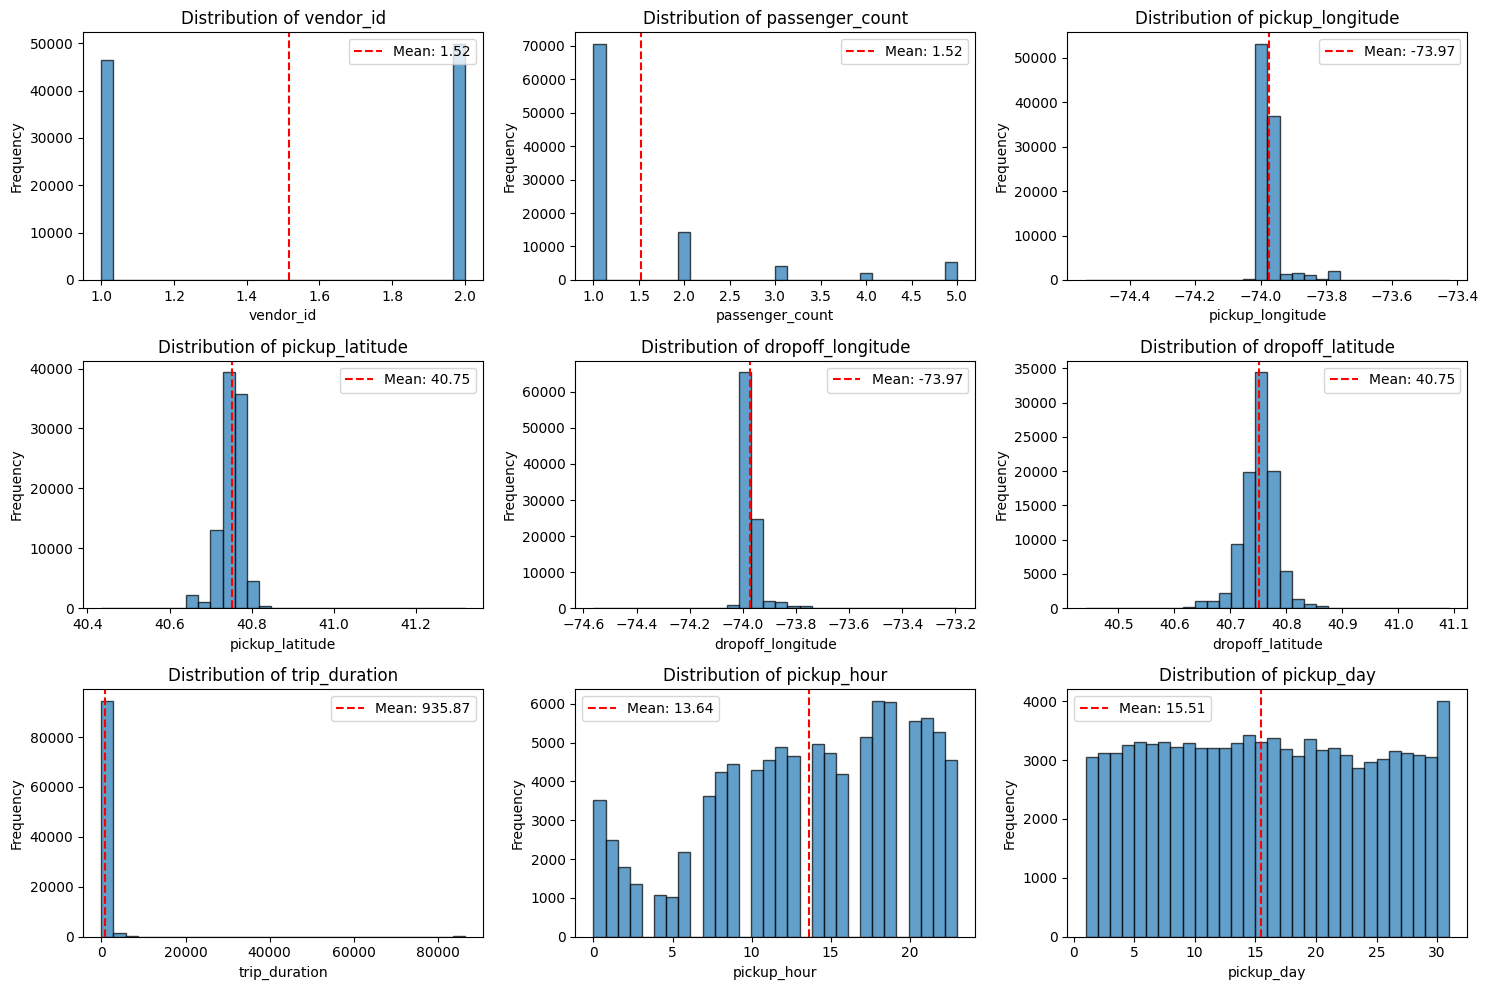

❌ No categorical columns found!
   Check your data dtypes with: data.dtypes


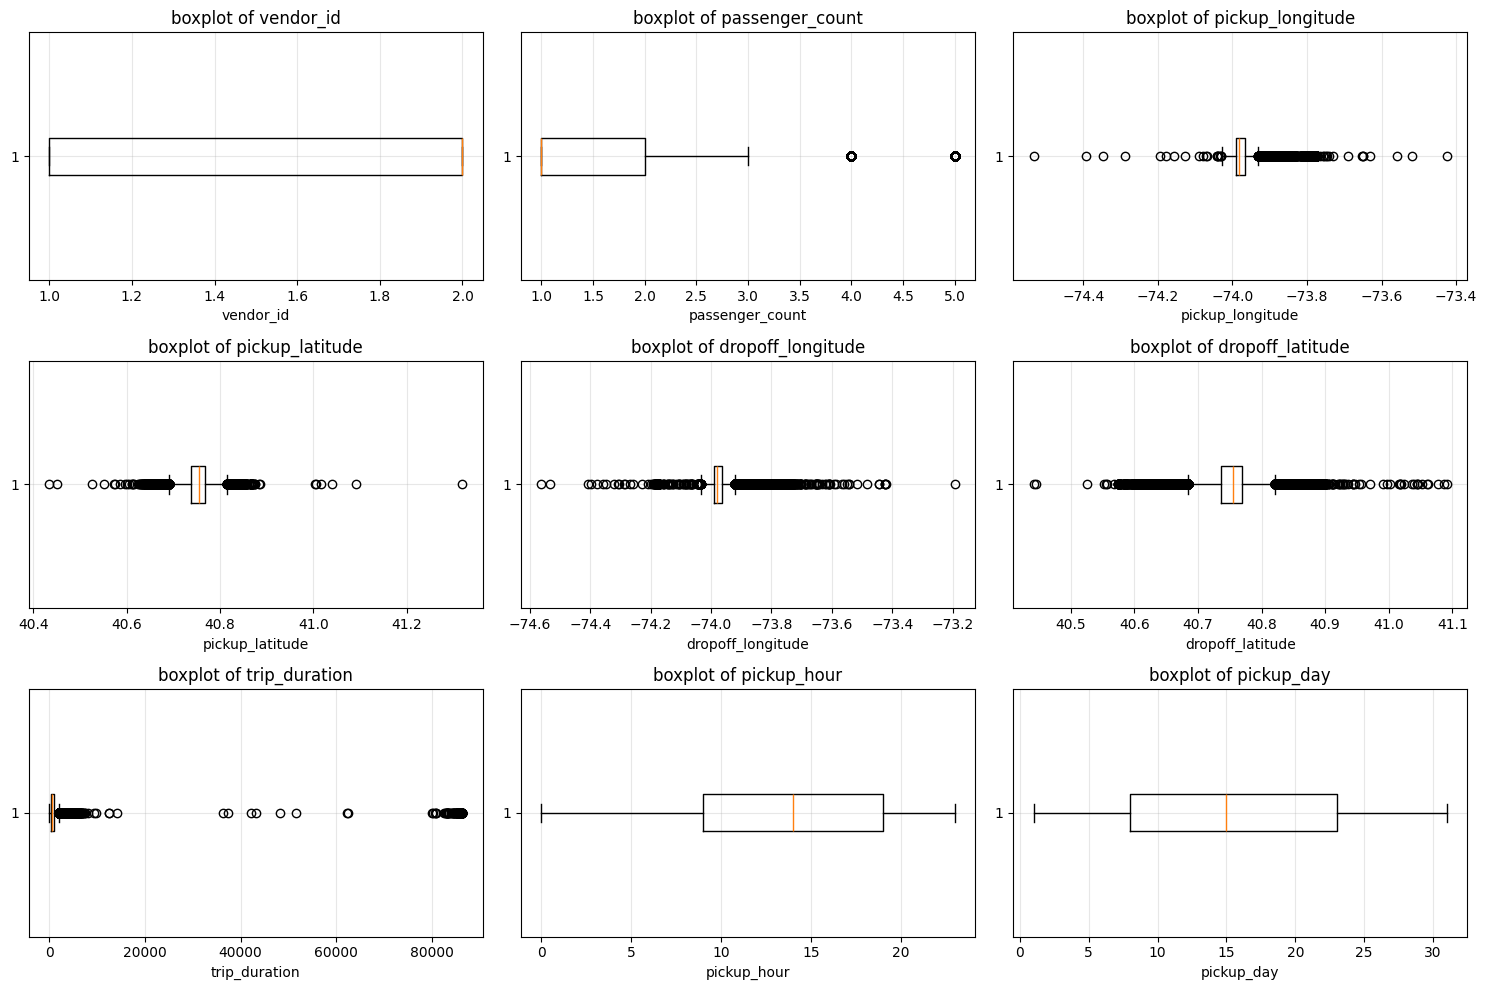

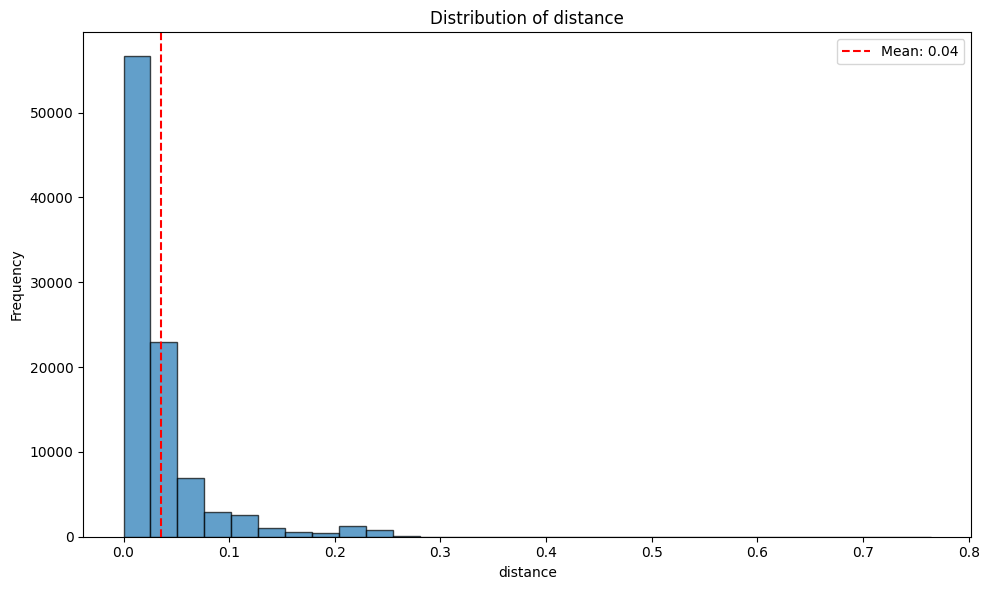

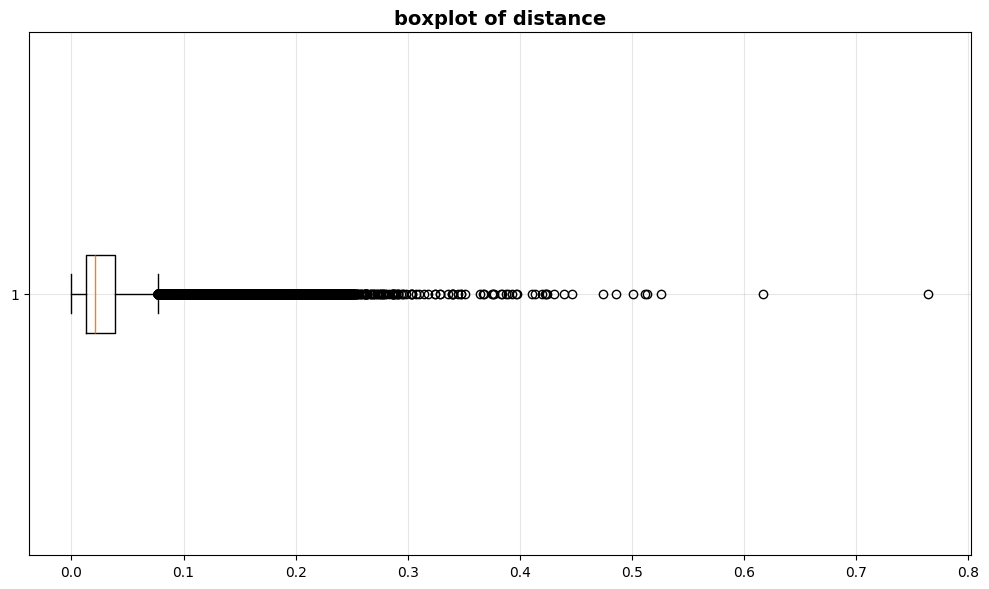

In [12]:
distribution(train)
plot_categorical(train)
boxplot(train)
distribution(train,'distance',figsize=(10,6))
boxplot(train,'distance',figsize=(10,6))

In [13]:
train['log_distance'] = np.log1p(train['distance'])

In [14]:
print(f"describe of all : \n \n {train.describe()}")

describe of all : 
 
           vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  96319.000000     96319.000000      96319.000000     96319.000000   
mean       1.517260         1.520136        -73.973570        40.751043   
std        0.499705         1.064807          0.037958         0.027988   
min        1.000000         1.000000        -74.533875        40.433842   
25%        1.000000         1.000000        -73.991875        40.737398   
50%        2.000000         1.000000        -73.981766        40.754211   
75%        2.000000         2.000000        -73.967354        40.768379   
max        2.000000         5.000000        -73.424973        41.319164   

       dropoff_longitude  dropoff_latitude  trip_duration   pickup_hour  \
count       96319.000000      96319.000000   96319.000000  96319.000000   
mean          -73.973561         40.751928     935.865219     13.640393   
std             0.036118          0.032284    2922.014366      6.381771   
mi

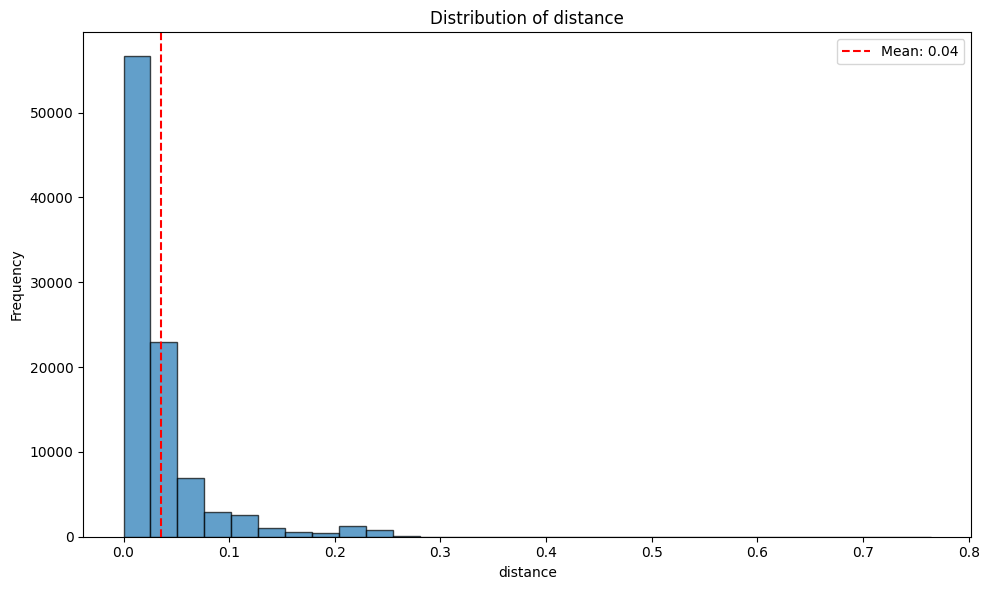

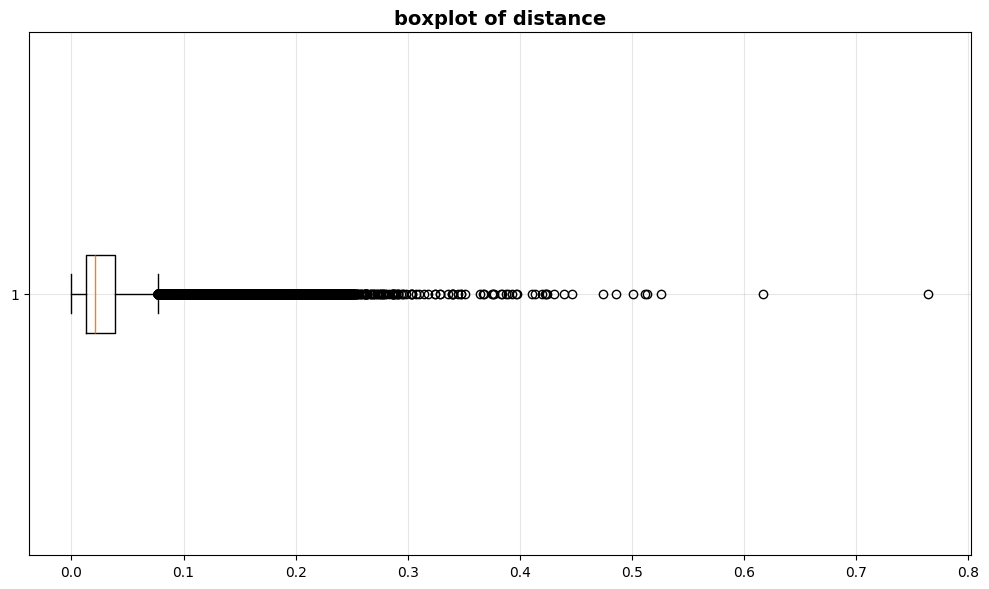

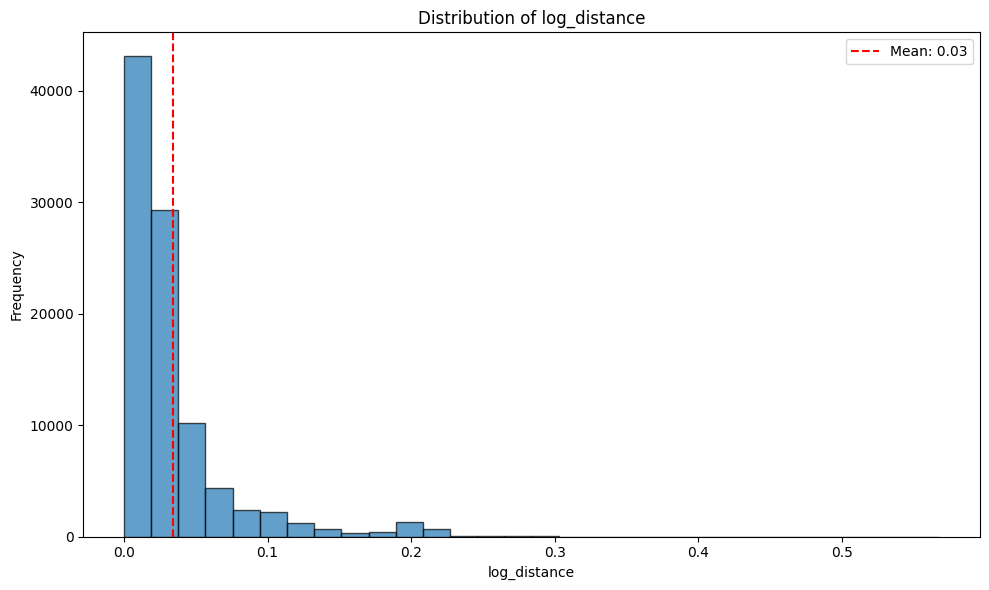

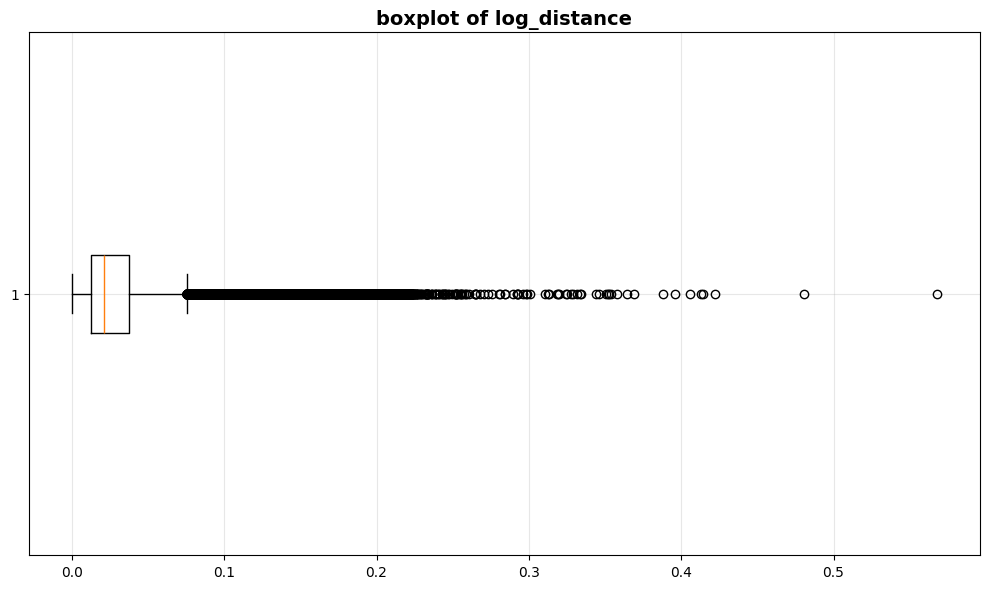

In [15]:

distribution(train,'distance',figsize=(10,6))
boxplot(train,'distance',figsize=(10,6))
distribution(train,'log_distance',figsize=(10,6))
boxplot(train,'log_distance',figsize=(10,6))

In [16]:
print(train['log_distance'].skew())

2.887676226487308


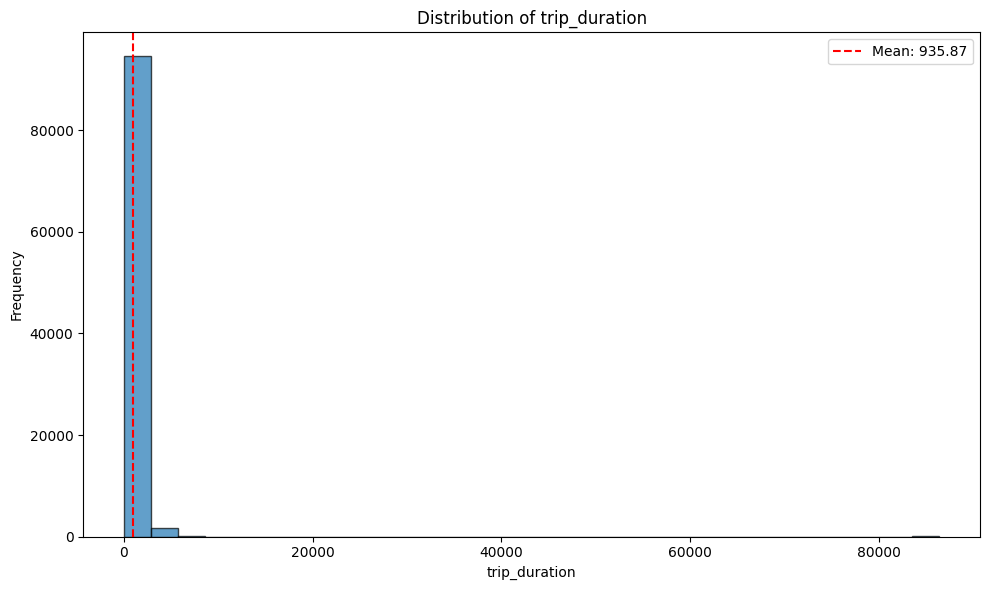

In [17]:
distribution(train,'trip_duration',figsize=(10,6))

In [18]:
import pandas as pd

def check_skewness(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    skew_data = []

    for col in num_cols:
        skew_val = df[col].skew()
        
        if skew_val > 1:
            status = "Highly Right Skewed"
        elif skew_val > 0.5:
            status = "Moderately Right Skewed"
        elif skew_val < -1:
            status = "Highly Left Skewed"
        elif skew_val < -0.5:
            status = "Moderately Left Skewed"
        else:
            status = "Normal"
            
        skew_data.append([col, skew_val, status])

    skew_df = pd.DataFrame(skew_data, columns=["Column", "Skewness", "Status"])
    
    return skew_df.sort_values(by="Skewness", ascending=False)

skew_report = check_skewness(train)
print(skew_report)

              Column   Skewness                  Status
6      trip_duration  27.138576     Highly Right Skewed
2   pickup_longitude   3.245527     Highly Right Skewed
7           distance   3.120344     Highly Right Skewed
8       log_distance   2.887676     Highly Right Skewed
4  dropoff_longitude   2.475439     Highly Right Skewed
1    passenger_count   2.271778     Highly Right Skewed
0          vendor_id  -0.069084                  Normal
5   dropoff_latitude  -0.313747                  Normal
3    pickup_latitude  -0.991944  Moderately Left Skewed


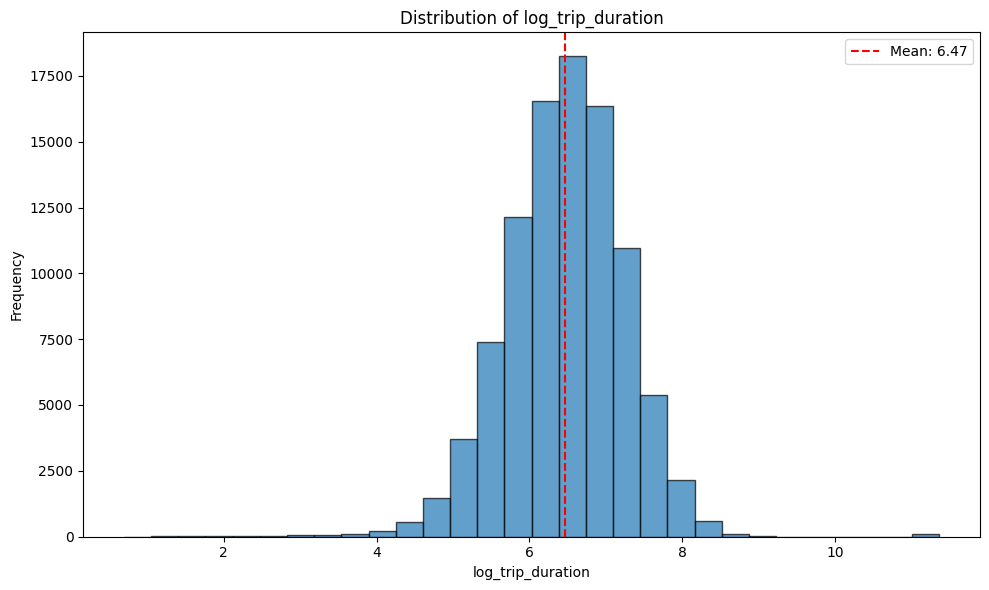

In [19]:
train['log_trip_duration'] = np.log1p(train['trip_duration'])
distribution(train,'log_trip_duration',figsize=(10,6))


In [20]:
skew_report = check_skewness(train)
print(skew_report)

              Column   Skewness                  Status
6      trip_duration  27.138576     Highly Right Skewed
2   pickup_longitude   3.245527     Highly Right Skewed
7           distance   3.120344     Highly Right Skewed
8       log_distance   2.887676     Highly Right Skewed
4  dropoff_longitude   2.475439     Highly Right Skewed
1    passenger_count   2.271778     Highly Right Skewed
0          vendor_id  -0.069084                  Normal
9  log_trip_duration  -0.233711                  Normal
5   dropoff_latitude  -0.313747                  Normal
3    pickup_latitude  -0.991944  Moderately Left Skewed


In [21]:
train = train.drop('trip_duration', axis=1)

In [22]:
X = train.drop('log_trip_duration', axis=1)
y = train['log_trip_duration']

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget summary:")
print(y.describe())

print("\nTarget skew:")
print(y.skew())

X shape: (96319, 12)
y shape: (96319,)

Missing values:
vendor_id            0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
pickup_hour          0
pickup_day           0
pickup_month         0
pickup_weekday       0
distance             0
log_distance         0
dtype: int64

Target summary:
count    96319.000000
mean         6.469812
std          0.783542
min          0.693147
25%          5.986452
50%          6.498282
75%          6.982863
max         11.366639
Name: log_trip_duration, dtype: float64

Target skew:
-0.23371062665432585


## 2. Model Training & Comparison

In [24]:
print(f"\n✅ Data Shape: {X.shape}")
print(f"✅ Features: {X.shape[1]}")
print(f"✅ Samples: {X.shape[0]}")
print(f"✅ Classes: {y.value_counts().to_dict()}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"\n✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")


✅ Data Shape: (96319, 12)
✅ Features: 12
✅ Samples: 96319
✅ Classes: {5.926926025970411: 122, 6.1092475827643655: 121, 5.855071922202427: 120, 5.8805329864007: 120, 5.988961416889864: 119, 6.09807428216624: 119, 6.129050210060545: 118, 6.0330862217988015: 117, 5.91350300563827: 116, 6.152732694704104: 116, 6.0112671744041615: 115, 5.823045895483019: 114, 5.796057750765372: 114, 6.013715156042802: 114, 6.240275845170769: 113, 5.908082938168931: 113, 5.932245187448011: 113, 6.309918278226516: 113, 5.730099782973574: 113, 5.641907070938114: 112, 6.018593214496234: 112, 5.84354441703136: 112, 5.942799375126701: 112, 5.6240175061873385: 112, 6.18826412308259: 111, 5.749392985908253: 111, 6.1903154058531475: 111, 6.091309882077698: 111, 6.025865973825314: 111, 5.736572297479192: 111, 5.953243334287785: 110, 5.993961427306569: 110, 5.998936561946683: 110, 6.1070228877422545: 110, 6.102558594613569: 109, 5.883322388488279: 109, 5.60947179518496: 108, 6.349138991379798: 108, 6.186208623900494:

In [25]:
print(X.dtypes)

vendor_id              int64
passenger_count        int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
pickup_hour            int32
pickup_day             int32
pickup_month           int32
pickup_weekday         int32
distance             float64
log_distance         float64
dtype: object


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, rmse, r2])

import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
results_df = results_df.sort_values("RMSE")

print(results_df)

               Model      RMSE        R2
6            XGBoost  0.409265  0.722996
4      Random Forest  0.418188  0.710785
5  Gradient Boosting  0.431560  0.691993
0  Linear Regression  0.538929  0.519670
1              Ridge  0.587742  0.428719
3      Decision Tree  0.597784  0.409030
2              Lasso  0.777610 -0.000001


In [27]:
# EVALUATE ALL MODELS
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)

results = []
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2
    })
    
    print(f"{name:25} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)

print("\n" + "="*70)
print(f"🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"   R² Score: {results_df.iloc[0]['R² Score']:.4f}")
print("="*70)


MODEL COMPARISON RESULTS
Linear Regression         | RMSE: 0.5389 | MAE: 0.3869 | R²: 0.5197
Ridge                     | RMSE: 0.5877 | MAE: 0.4289 | R²: 0.4287
Lasso                     | RMSE: 0.7776 | MAE: 0.5987 | R²: -0.0000
Decision Tree             | RMSE: 0.6036 | MAE: 0.3981 | R²: 0.3975
Random Forest             | RMSE: 0.4173 | MAE: 0.2762 | R²: 0.7120
Gradient Boosting         | RMSE: 0.4316 | MAE: 0.2944 | R²: 0.6920
XGBoost                   | RMSE: 0.4093 | MAE: 0.2635 | R²: 0.7230

🏆 Best Model: XGBoost
   RMSE: 0.4093
   R² Score: 0.7230


## 3. Hyperparameter Tuning (XGBoost)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [30]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [31]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}


In [32]:
best_xgb = random_search.best_estimator_

In [33]:
y_pred = best_xgb.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.4023379405543063
R2: 0.7322934652159068


In [34]:
best_xgb.fit(X,y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
print(test.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag'],
      dtype='str')


In [36]:
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])

test['pickup_hour'] = test['pickup_datetime'].dt.hour
test['pickup_day'] = test['pickup_datetime'].dt.day
test['pickup_month'] = test['pickup_datetime'].dt.month
test['pickup_weekday'] = test['pickup_datetime'].dt.weekday
test['distance'] = np.sqrt(
    (test['pickup_longitude'] - test['dropoff_longitude'])**2 +
    (test['pickup_latitude'] - test['dropoff_latitude'])**2
)
test['log_distance'] = np.log1p(test['distance'])
test_id = test['id']

test = test.drop(['id','pickup_datetime'],axis=1)

In [37]:
test = test[X.columns]

In [38]:
test_pred = best_xgb.predict(test)
test_pred = np.expm1(test_pred)

In [39]:
submission = pd.DataFrame({
    "id": test_id,
    "trip_duration": test_pred
})
submission.to_csv("submission.csv", index=False)



In [40]:
submission.head()

,id,trip_duration
0,id3004672,861.818054
1,id3505355,709.837891
2,id1217141,447.502655
3,id2150126,1012.552673
4,id1598245,306.597961


In [41]:
dummy_data = pd.DataFrame({
    "id": ["id_1", "id_2", "id_3"],
    "vendor_id": [1, 2, 1],
    "passenger_count": [2, 1, 3],
    "pickup_datetime": [
        "2016-03-15 08:30:00",
        "2016-04-20 18:45:00",
        "2016-05-10 12:15:00"
    ],
    "pickup_longitude": [-73.98, -73.95, -73.99],
    "pickup_latitude": [40.75, 40.78, 40.74],
    "dropoff_longitude": [-73.99, -73.96, -73.97],
    "dropoff_latitude": [40.76, 40.79, 40.75]
})

dummy_data['pickup_datetime'] = pd.to_datetime(dummy_data['pickup_datetime'])

dummy_data['pickup_hour'] = dummy_data['pickup_datetime'].dt.hour
dummy_data['pickup_day'] = dummy_data['pickup_datetime'].dt.day
dummy_data['pickup_month'] = dummy_data['pickup_datetime'].dt.month
dummy_data['pickup_weekday'] = dummy_data['pickup_datetime'].dt.weekday

dummy_data['distance'] = np.sqrt(
    (dummy_data['pickup_longitude'] - dummy_data['dropoff_longitude'])**2 +
    (dummy_data['pickup_latitude'] - dummy_data['dropoff_latitude'])**2
)

dummy_data['log_distance'] = np.log1p(dummy_data['distance'])
dummy_id = dummy_data['id']
dummy_data = dummy_data.drop(['id','pickup_datetime'] , axis=1)



In [42]:
dummy_data = dummy_data[X.columns]

In [43]:

dummy_pred = best_xgb.predict(dummy_data)
dummy_pred = np.expm1(dummy_pred)
result = pd.DataFrame({
    "id": dummy_id,
    "predicted_trip_duration": dummy_pred
})

print(result)

     id  predicted_trip_duration
0  id_1               699.721252
1  id_2               437.587158
2  id_3              1129.583252


VISUALIZATION OF THE 7 MODELS

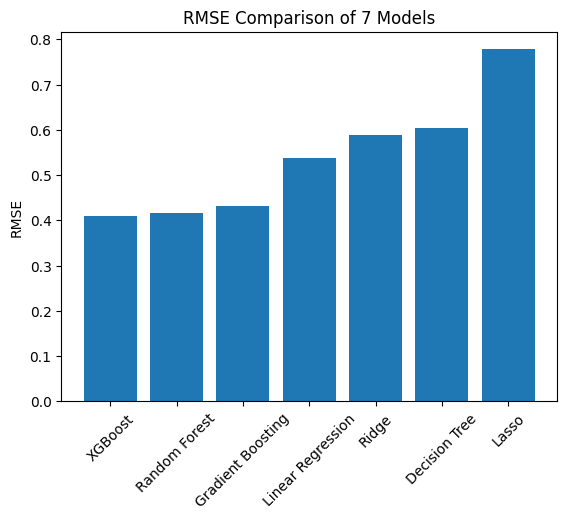

In [44]:
plt.figure()

plt.bar(results_df["Model"], results_df["RMSE"])

plt.xticks(rotation=45)
plt.title("RMSE Comparison of 7 Models")
plt.ylabel("RMSE")

plt.show()



In [45]:
plt.figure()
plt.bar(results_df['Model'],results_df['R2'])
plt.xticks(rotation=45)
plt.title("R2 score comparison")
plt.ylabel("R2 score")
plt.show()

KeyError: 'R2'

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

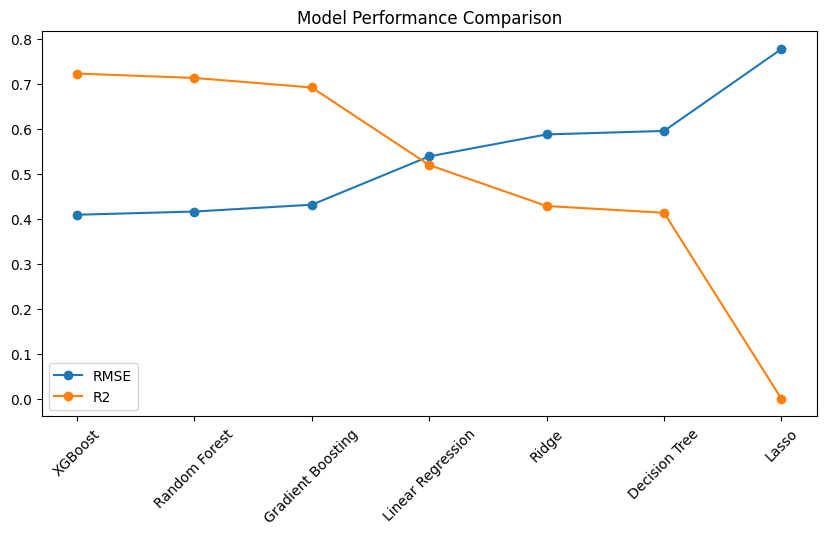

In [ ]:
plt.figure(figsize=(10,5))
plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["RMSE"], marker='o', label="RMSE")
plt.plot(results_df["Model"], results_df["R2"], marker='o', label="R2")

plt.xticks(rotation=45)
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

In [ ]:
best_model = results_df.iloc[0]
print(f"\n{'='*50}")
print(f"🎯 FINAL RESULTS")
print(f"{'='*50}")
print(f"Best Model:    {best_model['Model']}")
print(f"RMSE:          {best_model['RMSE']:.4f}")
print(f"MAE:           {best_model['MAE']:.4f}")
print(f"R² Score:      {best_model['R² Score']:.4f}")
print(f"{'='*50}\n")

 best model : XGBoost 
 RMSE : 0.4 
 R2:0.73


## 4. Final Model Evaluation

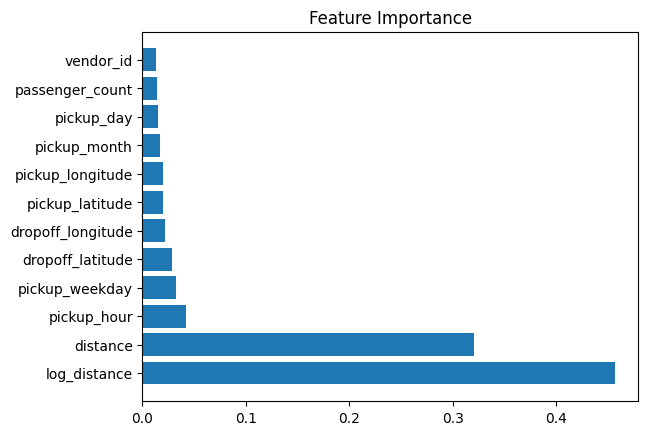

In [ ]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": best_xgb.feature_importances_
})

feat_imp = feat_imp.sort_values(by="importance", ascending=False)

plt.figure()

plt.barh(feat_imp["feature"], feat_imp["importance"])

plt.title("Feature Importance")

plt.show()

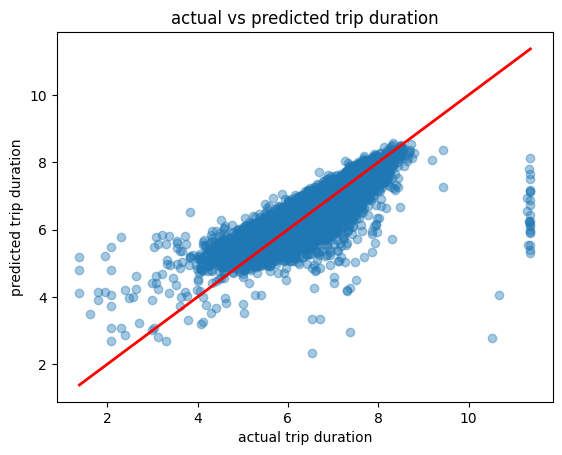

In [ ]:
plt.figure()
plt.scatter(y_val,y_pred ,alpha=0.4)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red',
    linewidth=2
)
plt.xlabel('actual trip duration')
plt.ylabel("predicted trip duration")
plt.title("actual vs predicted trip duration")
plt.show()